In [1]:
import numpy as np
import h5py
# f = h5py.File('Segmented_Linear_Baseline.mat','r')
# data = f.get('data/variable1')
# data = np.array(data) # For converting to a NumPy array


In [5]:
with h5py.File("../data/Segmented_Linear_Baseline.mat", "r") as f:
  # See what's at the top level
  # print(list(f.keys()))
      # See what's at the top level
      print(list(f.keys()))

      # Navigate into a group
      grp = f["Segmented_Linear_Baseline"]
      print(list(grp.keys()))   # signal names

      # Read a dataset directly
      data = np.array(grp["SpindleAccX"])   # shape: (N_runs, 1) of object refs

['#refs#', 'Segmented_Linear_Baseline']
['Bpos', 'Cpos', 'PlateHFAccZ', 'PlateLFAccX', 'PlateLFAccY', 'PlateLFAccZ', 'Power', 'RunNo', 'SpindleAccX', 'SpindleAccY', 'SpindleAccZ', 'SpindleLoad', 'SpindleSpeed', 'Time', 'TimeZero', 'Xpos', 'Ypos', 'Zpos']


In [3]:
  import pandas as pd

  df = pd.read_parquet("parquet_output/Segmented_Linear_Baseline.parquet")

  df.head()
  df.shape
  df.dtypes
  df.describe()

  # You can also load just specific columns to keep memory low:

  # Only load the spindle X channel + metadata
  df = pd.read_parquet(
      "parquet_output/Segmented_Linear_Baseline.parquet",
      columns=["routine", "fault_mode", "run", "sample", "SpindleAccX"]
  )

  # Or filter to a single run without loading everything:

  # import pyarrow.parquet as pq

  # # Read with a filter — only loads matching row groups into memory
  # df = pq.read_table(
  #     "code/parquet_output/Segmented_Linear_Baseline.parquet",
  #     filters=[("run", "=", 1)]
  # ).to_pandas()

In [4]:
df.head()

,routine,fault_mode,run,sample,SpindleAccX
0,Linear,Baseline,1,1,-0.021618
1,Linear,Baseline,1,2,-0.006295
2,Linear,Baseline,1,3,0.072822
3,Linear,Baseline,1,4,-0.041947
4,Linear,Baseline,1,5,0.000359


In [6]:
import pyarrow.parquet as pq

df_run1 = pq.read_table(
  "parquet_output/Segmented_Linear_Baseline.parquet",
  filters=[("run", "=", 1)]
).to_pandas()

In [7]:
df_run1.head()

,routine,fault_mode,run,sample,SpindleAccX,SpindleAccY,SpindleAccZ,PlateLFAccX,PlateLFAccY,PlateLFAccZ,PlateHFAccZ,Power
0,Linear,Baseline,1,1,-0.021618,0.026276,0.009755,-0.005379,-0.020422,-0.010810,-0.180629,0.039548
1,Linear,Baseline,1,2,-0.006295,-0.006486,-0.002931,-0.008518,-0.019000,-0.007815,-0.164928,0.039548
2,Linear,Baseline,1,3,0.072822,-0.037966,0.016647,-0.010124,-0.019449,-0.014740,-0.145862,0.039548
3,Linear,Baseline,1,4,-0.041947,-0.018993,0.024698,-0.008966,-0.015483,-0.011409,-0.134647,0.039548
4,Linear,Baseline,1,5,0.000359,0.016271,0.070135,-0.010199,-0.018626,-0.008152,-0.131657,0.039548


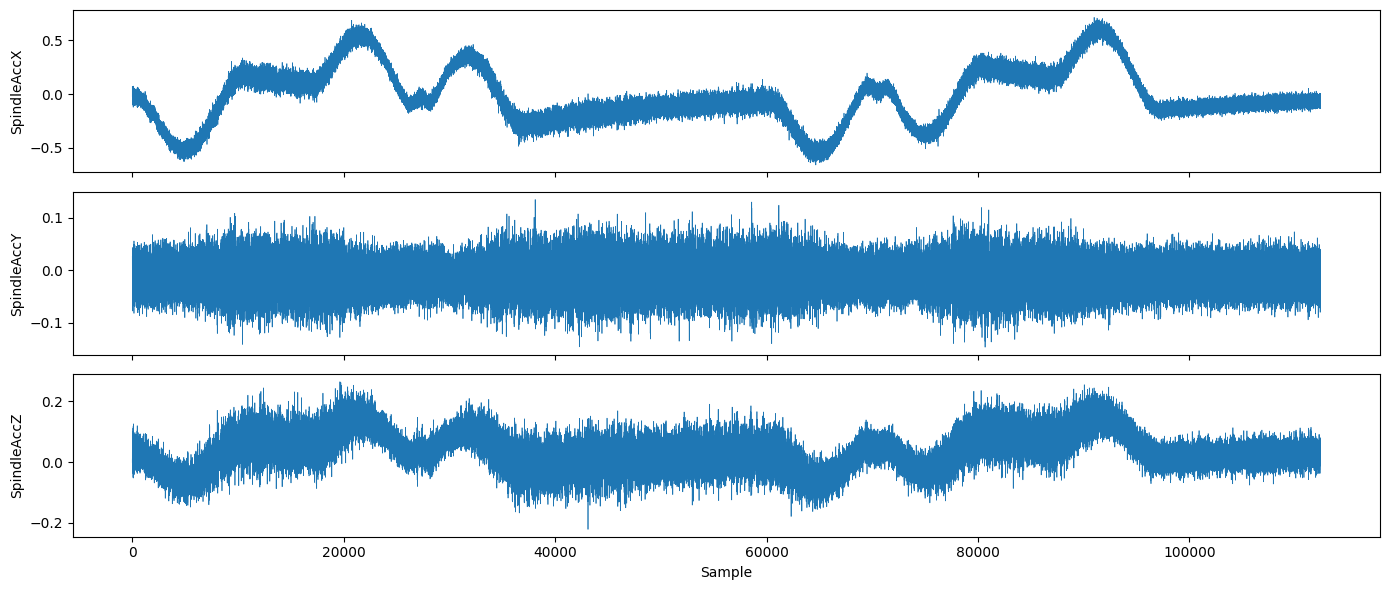

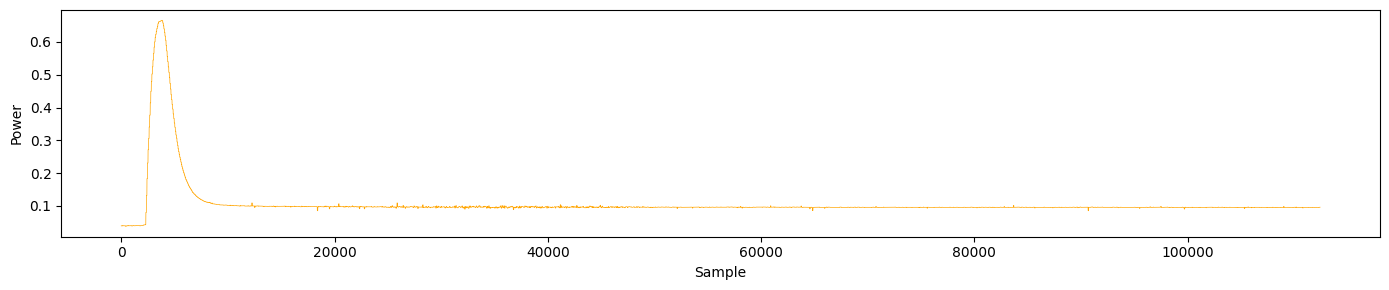

In [10]:
import matplotlib.pyplot as plt

fig, axes = plt.subplots(3, 1, figsize=(14, 6), sharex=True)

for ax, col in zip(axes, ["SpindleAccX", "SpindleAccY", "SpindleAccZ"]):
  ax.plot(df_run1["sample"], df_run1[col], lw=0.5)
  ax.set_ylabel(col)

axes[-1].set_xlabel("Sample")
plt.tight_layout()
plt.show()

plt.figure(figsize=(14, 3))
plt.plot(df_run1["sample"], df_run1["Power"], lw=0.5, color="orange")
plt.ylabel("Power")
plt.xlabel("Sample")
plt.tight_layout()
plt.show()